# Mental Health

## dependencies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

## data and configuration

In [ ]:
# kaggle api configuration
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# downloading the fer2013 dataset
!kaggle datasets download -d bhavikjikadara/mental-health-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.95M/1.95M [00:01<00:00, 1.19MB/s]



In [ ]:
!ls

kaggle.json  mental-health-dataset.zip	sample_data


In [ ]:
# unzipping the mental health data
!unzip /content/mental-health-dataset.zip -d /content/


Archive:  /content/mental-health-dataset.zip
  inflating: /content/Mental Health Dataset.csv  


In [ ]:
!ls

 kaggle.json		      mental-health-dataset.zip
'Mental Health Dataset.csv'   sample_data


In [ ]:
data = pd.read_csv("/content/Mental Health Dataset.csv")
data.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


## what are we predicting bytheway:\
  --> probability that a person seeks professional mental health treatment

## exploratory data analysis

In [ ]:
#data shape
data.shape

(292364, 17)

In [ ]:
# columns
data.columns

Index(['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed',
       'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress',
       'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
       'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

In [ ]:
# basic data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [ ]:
# value counts
columns = data.columns.tolist()
for column in columns:
  print(data[column].value_counts())
  print("*"*50)
  print("\n\n")

Timestamp
8/27/2014 11:43    2384
8/27/2014 12:31    2340
8/27/2014 12:53    1648
8/27/2014 16:21    1604
8/27/2014 12:39    1604
                   ... 
9/11/2014 17:00     390
9/13/2014 7:52      390
9/14/2014 9:04      390
9/23/2014 20:05     390
9/2/2014 3:13       390
Name: count, Length: 580, dtype: int64
**************************************************



Gender
Male      239850
Female     52514
Name: count, dtype: int64
**************************************************



Country
United States             171308
United Kingdom             51404
Canada                     18726
Australia                   6026
Netherlands                 5894
Ireland                     5548
Germany                     4680
Sweden                      2818
India                       2774
France                      2340
Brazil                      2340
New Zealand                 1994
South Africa                1994
Italy                       1560
Switzerland                 1560
Israel   

In [ ]:
columns

['Timestamp',
 'Gender',
 'Country',
 'Occupation',
 'self_employed',
 'family_history',
 'treatment',
 'Days_Indoors',
 'Growing_Stress',
 'Changes_Habits',
 'Mental_Health_History',
 'Mood_Swings',
 'Coping_Struggles',
 'Work_Interest',
 'Social_Weakness',
 'mental_health_interview',
 'care_options']

In [ ]:
# removing timestamp and country
data = data.drop(columns=["Timestamp", "Country"])
data.columns

Index(['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment',
       'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')

In [ ]:
data.shape

(292364, 15)

In [ ]:
# target value counts
data['treatment'].value_counts()

,count
treatment,
Yes,147606
No,144758


In [ ]:
# checking for null values
data.isnull().sum()

,0
Gender,0
Occupation,0
self_employed,5202
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0
Mental_Health_History,0
Mood_Swings,0


In [ ]:
# dropping missing values
data = data.dropna()

In [ ]:
data.isnull().sum()

,0
Gender,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0
Mental_Health_History,0
Mood_Swings,0


In [ ]:
data.shape

(287162, 15)

In [ ]:
data.columns

Index(['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment',
       'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')

In [ ]:
columns = data.columns.tolist()
columns

['Gender',
 'Occupation',
 'self_employed',
 'family_history',
 'treatment',
 'Days_Indoors',
 'Growing_Stress',
 'Changes_Habits',
 'Mental_Health_History',
 'Mood_Swings',
 'Coping_Struggles',
 'Work_Interest',
 'Social_Weakness',
 'mental_health_interview',
 'care_options']

In [ ]:
data.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,Female,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,Female,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No


## encoding

In [ ]:
# binary columns

binary_map = {
    "Yes": 1,
    "No": 2
}

# binary columns
binary_columns = [
    'self_employed', 'family_history', 'treatment',
    'Growing_Stress', 'Changes_Habits', 'Mental_Health_History',
    'Coping_Struggles', 'Work_Interest', 'Social_Weakness'
]

for column in binary_columns:
  data[column] = data[column].map(binary_map)

In [ ]:
data.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,Female,Corporate,2,1,1,1-14 days,1.0,2.0,1.0,Medium,2,2.0,1.0,Maybe,Yes
4,Female,Corporate,2,1,1,1-14 days,1.0,2.0,1.0,Medium,2,2.0,1.0,No,Yes
5,Female,Corporate,2,2,1,1-14 days,1.0,2.0,1.0,Medium,2,2.0,1.0,Maybe,Not sure
6,Female,Corporate,2,1,1,1-14 days,1.0,2.0,1.0,Medium,2,2.0,1.0,No,Not sure
7,Female,Corporate,2,2,2,1-14 days,1.0,2.0,1.0,Medium,2,2.0,1.0,No,No


In [ ]:
data["Mood_Swings"].value_counts()

,count
Mood_Swings,
Medium,99272
Low,98062
High,89828


In [ ]:
data["Days_Indoors"].value_counts()

,count
Days_Indoors,
1-14 days,62429
31-60 days,59625
Go out Every day,57323
More than 2 months,54918
15-30 days,52867


In [ ]:
# days and mood map ordinal encoding
days_map = {
    '0-1 days': 0,
    '1-14 days': 1,
    '15-30 days': 2,
    '31+ days': 3
}

mood_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

data["Days_Indoors"] = data["Days_Indoors"].map(days_map)
data["Mood_Swings"] = data["Mood_Swings"].map(mood_map)

In [ ]:
data.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,Female,Corporate,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,Maybe,Yes
4,Female,Corporate,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,No,Yes
5,Female,Corporate,2,2,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,Maybe,Not sure
6,Female,Corporate,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,No,Not sure
7,Female,Corporate,2,2,2,1.0,1.0,2.0,1.0,1,2,2.0,1.0,No,No


In [ ]:
# one hot encoding nominal columns

nominal_cols = [
    'Gender',
    'Occupation',
    'mental_health_interview',
    'care_options'
]

one_hot_encoder = OneHotEncoder(
    drop = "first",
    handle_unknown = "ignore",
    sparse_output = False
)

# fitting
one_hot_encoder.fit(data[nominal_cols])
encoded = one_hot_encoder.transform(data[nominal_cols])

# to dataframe again
encoded_df = pd.DataFrame(
    encoded,
    columns=one_hot_encoder.get_feature_names_out(nominal_cols)
)

data = data.drop(columns=nominal_cols).reset_index(drop=True)
data = pd.concat([data, encoded_df], axis=1)

In [ ]:
data.shape

(287162, 20)

In [ ]:
data.head()

,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,Gender_Male,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,mental_health_interview_No,mental_health_interview_Yes,care_options_Not sure,care_options_Yes
0,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2,2,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,2,2,2,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


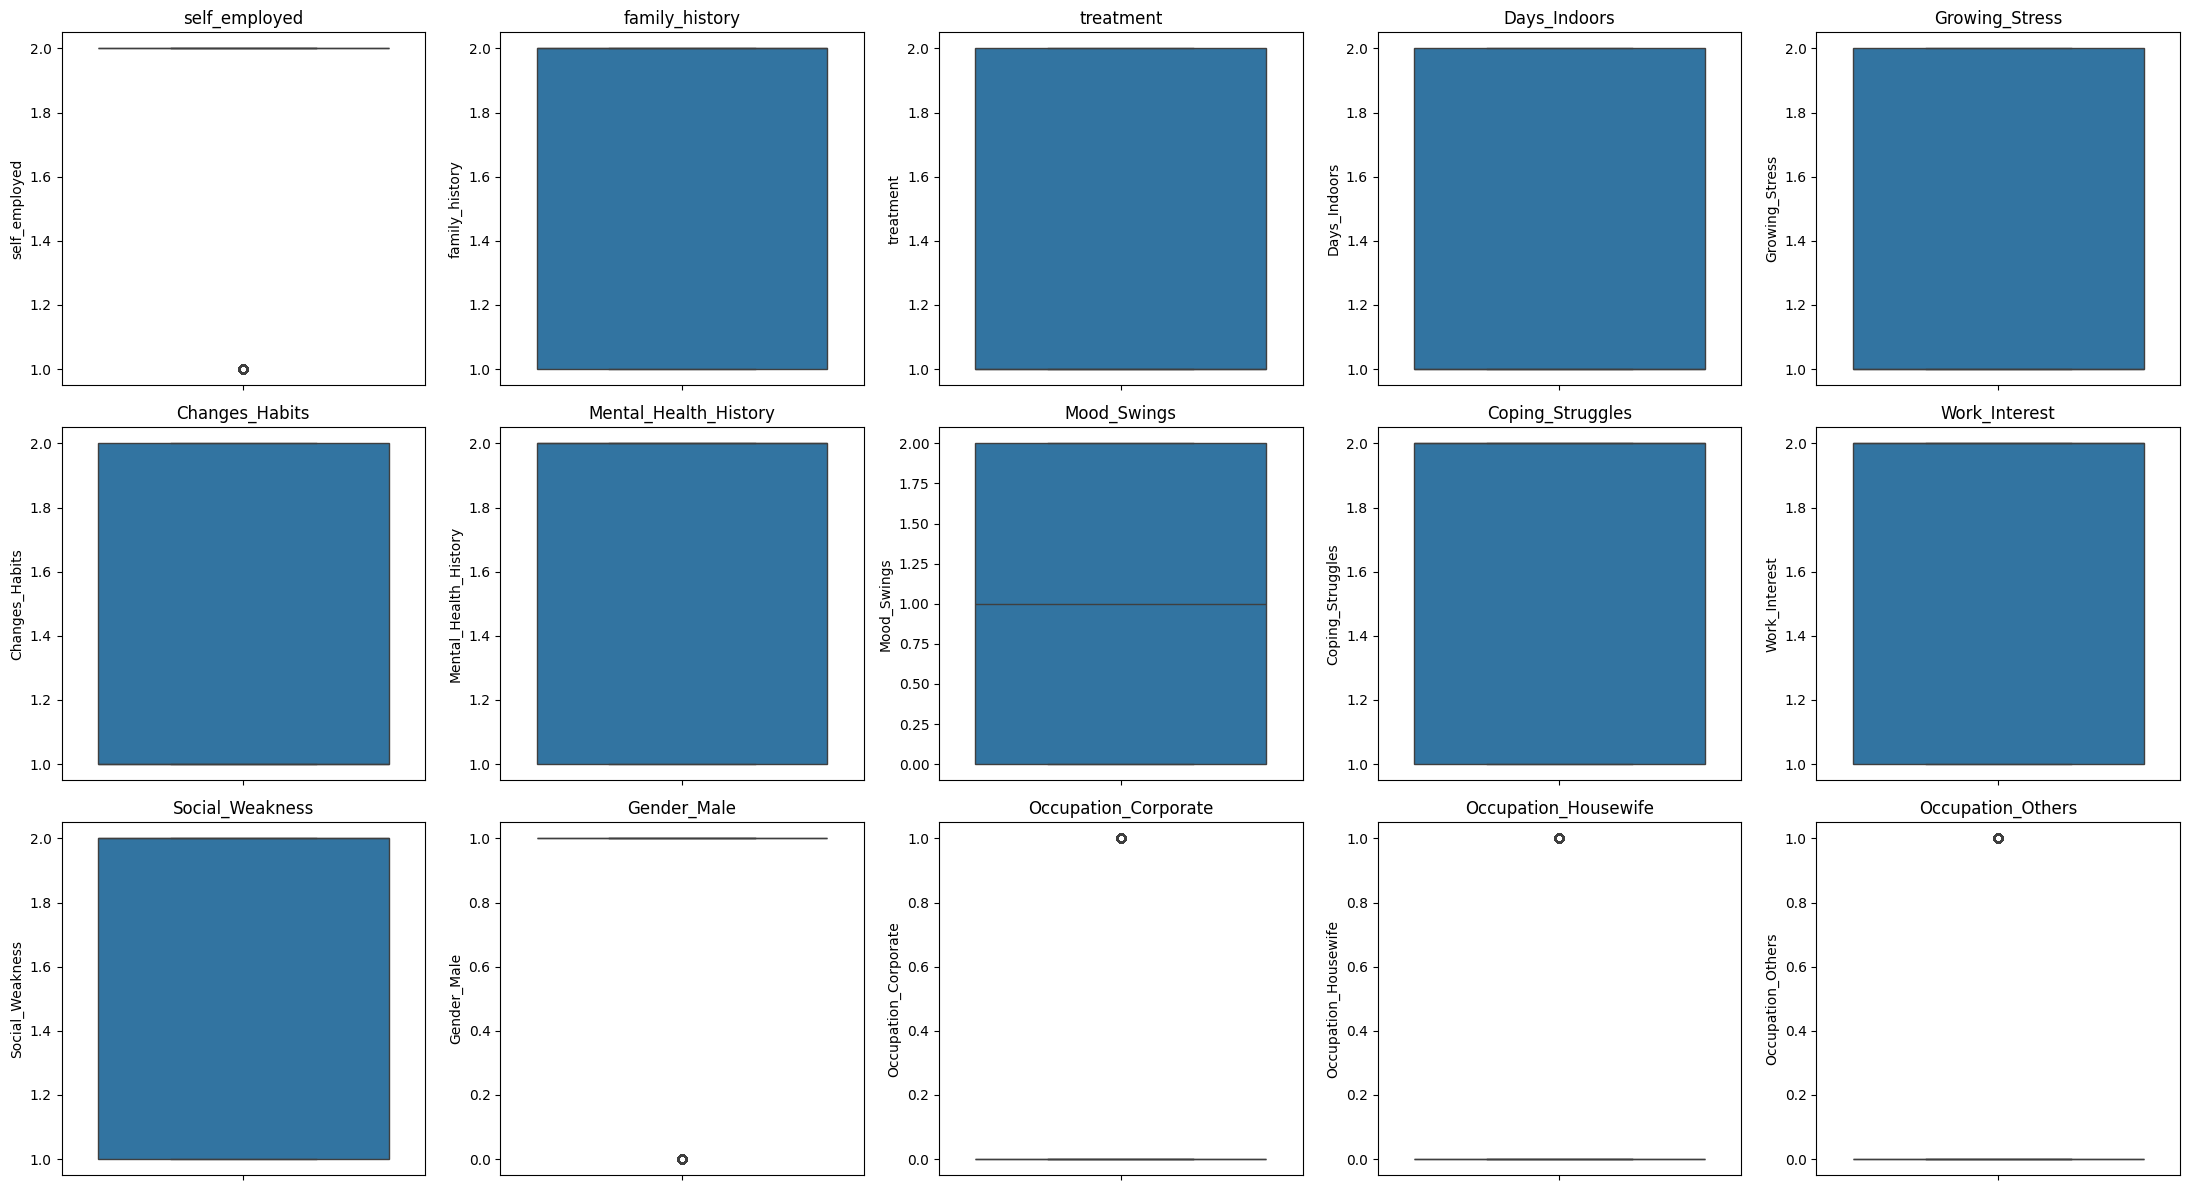

In [35]:
# plotting boxplot
numeric_cols = data.select_dtypes(include="number").columns

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for idx, column in enumerate(numeric_cols[:len(axes)]):
    sns.boxplot(
        data=data,
        y=column,
        ax=axes[idx]
    )
    axes[idx].set_title(column)

# remove unused plots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [36]:
data.head()

,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,Gender_Male,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,mental_health_interview_No,mental_health_interview_Yes,care_options_Not sure,care_options_Yes
0,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2,2,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,1,1,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,2,2,2,1.0,1.0,2.0,1.0,1,2,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
